## regression notes

In [2]:
import pandas as pd
import subprocess
import requests
import numpy as np

In [3]:
df = pd.read_csv('/Users/foroghakbari/Zoomcamp/ml_course/zoomcamp_ml/regression/data.csv')

In [4]:
df.head()
df.columns.str.lower()

Index(['make', 'model', 'year', 'engine fuel type', 'engine hp',
       'engine cylinders', 'transmission type', 'driven_wheels',
       'number of doors', 'market category', 'vehicle size', 'vehicle style',
       'highway mpg', 'city mpg', 'popularity', 'msrp'],
      dtype='object')

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

In [7]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [8]:
df.dtypes[df.dtypes == 'object']

make                 object
model                object
engine_fuel_type     object
transmission_type    object
driven_wheels        object
market_category      object
vehicle_size         object
vehicle_style        object
dtype: object

In [9]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [10]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [11]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [12]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='msrp', ylabel='Count'>

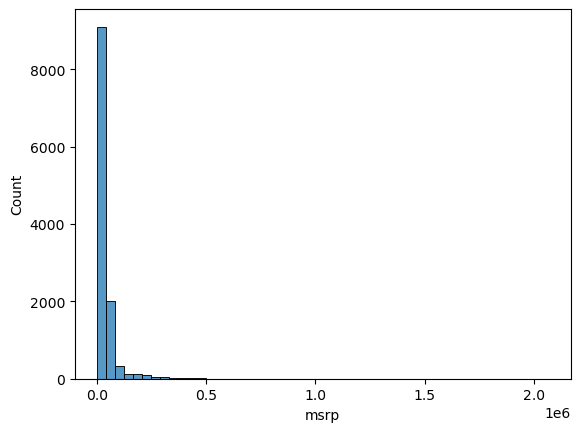

In [14]:
sns.histplot(df.msrp, bins=50)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='msrp', ylabel='Count'>

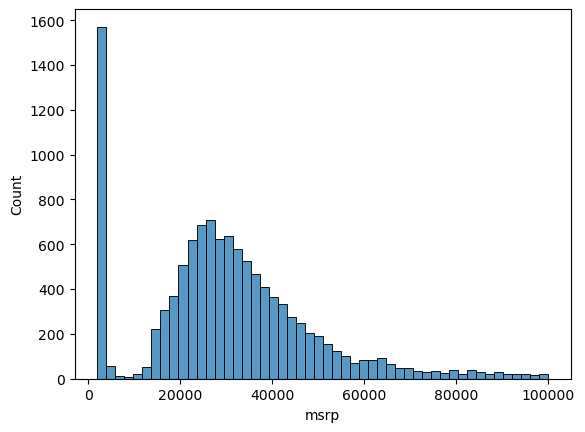

In [15]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50) #to get  a better view of the distribution

In [16]:
np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000 + 1])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [17]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [18]:
price_logs = np.log1p(df.msrp)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='msrp', ylabel='Count'>

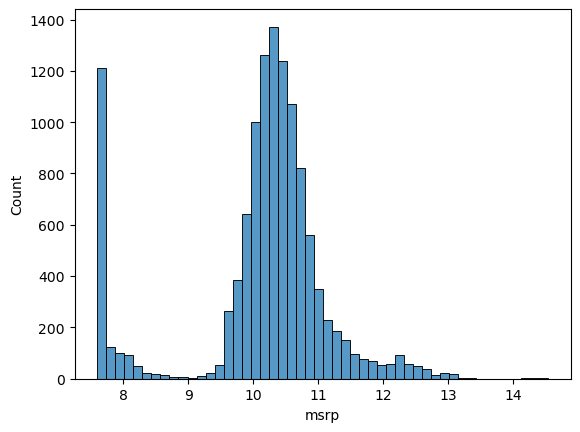

In [19]:
sns.histplot(price_logs, bins=50) #looks more normal distributed

In [20]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [21]:
## training, validation and testing

In [22]:
n =len(df)

In [23]:
n

11914

In [24]:
n_val = int(n * 0.2) #to do a 60/20/20 split- to calculate how many records have 20%
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [25]:
n, n_val, n_test, n_train

(11914, 2382, 2382, 7150)

In [26]:
df.iloc[:10]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


In [27]:
df.iloc[:10]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


In [28]:
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val+n_test]
df_train = df.iloc[n_val+n_test:]

#issue here is that its sequential and not random e.g. all one type of car is at the front etc. so the data is not representative.

In [29]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,porsche,cayenne,2016,premium_unleaded_(required),570.0,8.0,automatic,all_wheel_drive,4.0,"crossover,luxury,high-performance",midsize,4dr_suv,21,14,1715,157300
2378,porsche,cayenne,2016,diesel,240.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury,diesel",midsize,4dr_suv,29,20,1715,62300
2379,porsche,cayenne,2017,premium_unleaded_(required),520.0,8.0,automatic,all_wheel_drive,4.0,"crossover,luxury,performance",midsize,4dr_suv,21,14,1715,116500
2380,porsche,cayenne,2017,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,24,18,1715,59600


In [30]:
#need to random shuffle, using numpy to shuffle an arbitrary sequence 

idx = np.arange(n)
np.random.shuffle(idx)

In [31]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [32]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
832,saab,9-3,2009,premium_unleaded_(recommended),210.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,28,19,376,34150
7512,honda,passport,2002,regular_unleaded,205.0,6.0,automatic,four_wheel_drive,4.0,NaN,midsize,4dr_suv,19,15,2202,27600
2941,toyota,corolla,2016,regular_unleaded,132.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,37,28,2031,21665
11837,gmc,yukon_hybrid,2012,regular_unleaded,332.0,8.0,automatic,four_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,549,55280
11495,bmw,x3,2016,premium_unleaded_(required),240.0,4.0,automatic,all_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,28,21,3916,40950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7871,infiniti,q70,2016,premium_unleaded_(required),330.0,6.0,automatic,all_wheel_drive,4.0,"luxury,performance",large,sedan,24,18,190,53500
6909,lincoln,mkz,2017,premium_unleaded_(recommended),245.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,28,20,61,36900
10847,nissan,truck,1995,regular_unleaded,153.0,6.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,20,16,2009,2121
2062,mercedes-benz,c-class,2015,premium_unleaded_(required),241.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,34,25,617,38400


In [33]:
#one more issue- getting different records first car will not be a porsche / gmc- REPRODUCIBLE.
#set a random seed
np.random.seed(2)

idx = np.arange(n)
np.random.shuffle(idx)

In [34]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [35]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [36]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [37]:
y_train

array([10.98530967,  7.60140233, 10.41018467, ..., 10.32649784,
        9.76428295,  7.69802917])

In [38]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [39]:
#linear regression

In [40]:
xi = [453, 11, 86]
w0 = 7.17 #intercept/bias term
w = [0.01, 0.04, 0.002]

In [41]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [42]:
linear_regression(xi)

12.312

In [43]:
#w0 when we have no predictors/know nothing about the car

In [44]:
#log transformation 
np.expm1(12.312)

222347.2221101062

In [45]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [46]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [47]:
w_new = [w0] + w

In [48]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [49]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [50]:
linear_regression(xi)

12.312

In [51]:
xi = [453, 11, 86]
w0 = 7.17 #intercept/bias term
w = [0.01, 0.04, 0.002]

In [52]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)

In [53]:
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [54]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [55]:
#function 
def linear_regression(X):
    return X.dot(w_new)

In [58]:
price=linear_regression(X) #in logs

In [60]:
dollar= np.expm1(price)

In [61]:
dollar

array([237992.82334859, 768348.51018973, 222347.22211011])

In [ ]:
#training lM

In [92]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)

In [77]:
XTX = X.T.dot(X)

In [78]:
XTX

array([[ 696471,   44115,  718540],
       [  44115,    7146,  118803],
       [ 718540,  118803, 6359986]])

In [79]:
#Inverse
XTX_inv = np.linalg.inv(XTX)

In [80]:
XTX.dot(XTX_inv).round(1)

array([[ 1.,  0.,  0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [93]:
#target 
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

In [82]:
#equation 
w_full = XTX_inv.dot(X.T).dot(y)

In [74]:
w_full 

array([ 3.00067767e+02, -2.27742529e-01, -2.57694130e+00, -2.30120640e-02])

In [83]:
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

In [84]:
w0 = w_full[0]
w = w_full[1:]

In [91]:
w0, w

(300.0677669255554, array([-0.22774253, -2.5769413 , -0.02301206]))

In [87]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [94]:
train_linear_regression(X, y)

(300.0677669255554, array([-0.22774253, -2.5769413 , -0.02301206]))

In [95]:
## pred for car

In [98]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [99]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

In [100]:
base = ['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']

In [101]:
base

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [102]:
X_train = df_train[base].values

In [103]:
X_train

array([[ 455.,    8.,   29.,   17., 1385.],
       [  95.,    4.,   24.,   21.,  481.],
       [ 305.,    6.,   24.,   17., 1385.],
       ...,
       [ 278.,    6.,   23.,   18., 2031.],
       [ 130.,    4.,   30.,   24., 1720.],
       [ 222.,    6.,   23.,   17., 1851.]])

In [104]:
y_train

array([10.98530967,  7.60140233, 10.41018467, ..., 10.32649784,
        9.76428295,  7.69802917])

In [105]:
train_linear_regression(X_train, y_train) #all nans, missing values

(nan, array([nan, nan, nan, nan, nan]))

In [110]:
#fill nans with 0s
df_train[base].isnull().sum()

engine_hp           35
engine_cylinders    17
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [111]:
X_train = df_train[base].fillna(0)
#best way to deal with missing data?

In [112]:
w0, w = train_linear_regression(X_train, y_train) #all nans, missing values

In [113]:
y_pred = w0 + X_train.dot(w)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

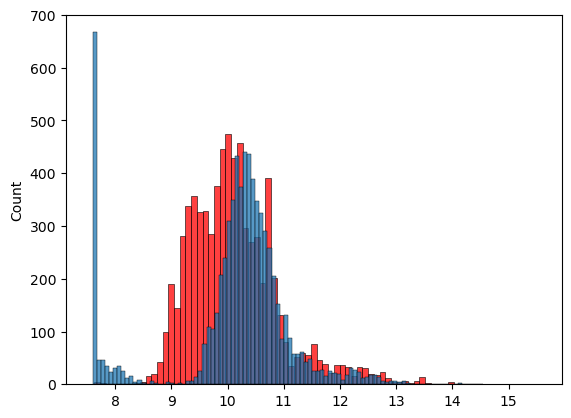

In [119]:
sns.histplot(y_pred, color='red')
sns.histplot(y_train)

In [120]:
#RMSE

In [ ]:
#how can we quantify how 'off' predictions are from target y?

In [121]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error **2
    mse= se.mean()
    return np.sqrt(mse)

In [122]:
rmse(y_train, y_pred)

0.741874718712102

In [ ]:
#validation

In [127]:
base = ['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train) #all nans, missing values
y_pred = w0 + X_train.dot(w)

In [129]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [130]:
X_train = prepare_X(df_train)

In [132]:
w0, w = train_linear_regression(X_train, y_train) 

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

In [133]:
rmse(y_val, y_pred)

0.7525369307569661

In [ ]:
#feature engineering

In [136]:
df_train.year.max()

2017

In [137]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df.year
    features = base +['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [138]:
X_train = prepare_X(df_train)

In [139]:
X_train

array([[4.550e+02, 8.000e+00, 2.900e+01, 1.700e+01, 1.385e+03, 2.000e+00],
       [9.500e+01, 4.000e+00, 2.400e+01, 2.100e+01, 4.810e+02, 2.000e+01],
       [3.050e+02, 6.000e+00, 2.400e+01, 1.700e+01, 1.385e+03, 1.000e+00],
       ...,
       [2.780e+02, 6.000e+00, 2.300e+01, 1.800e+01, 2.031e+03, 1.000e+00],
       [1.300e+02, 4.000e+00, 3.000e+01, 2.400e+01, 1.720e+03, 1.000e+00],
       [2.220e+02, 6.000e+00, 2.300e+01, 1.700e+01, 1.851e+03, 2.300e+01]])

In [140]:
w0, w = train_linear_regression(X_train, y_train) 

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

0.5258089730607122

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

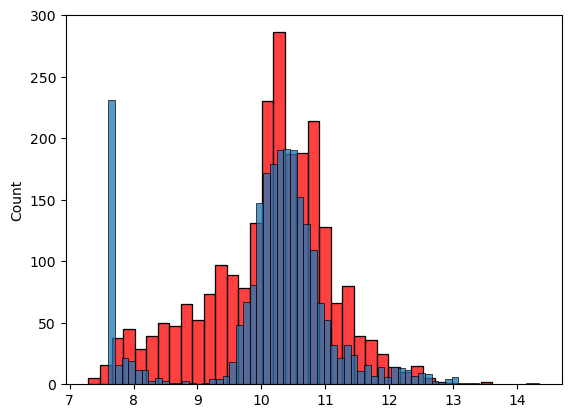

In [141]:
sns.histplot(y_pred, color='red')
sns.histplot(y_val)

In [ ]:
#cateogorical variables

In [ ]:
#number of doors

In [148]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,corvette,2015,premium_unleaded_(recommended),455.0,8.0,manual,rear_wheel_drive,2.0,high-performance,compact,convertible,29,17,1385
1,suzuki,sidekick,1997,regular_unleaded,95.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,convertible_suv,24,21,481
2,chevrolet,colorado,2016,regular_unleaded,305.0,6.0,automatic,four_wheel_drive,4.0,diesel,compact,crew_cab_pickup,24,17,1385
3,volkswagen,gli,2012,premium_unleaded_(recommended),200.0,4.0,manual,front_wheel_drive,4.0,performance,midsize,sedan,33,22,873
4,bentley,continental_gt,2016,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,coupe,25,15,520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,audi,a4,2016,premium_unleaded_(required),220.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,31,22,3105
7146,dodge,ram_cargo,2003,regular_unleaded,175.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,15,13,1851
7147,toyota,tacoma,2016,regular_unleaded,278.0,6.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,23,18,2031
7148,kia,soul,2016,regular_unleaded,130.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,wagon,30,24,1720


In [151]:
df_train['num_doors_2']=(df_train.number_of_doors == 2).astype('int')
df_train['num_doors_4']=(df_train.number_of_doors == 4).astype('int')
df_train['num_doors_4']=(df_train.number_of_doors == 4).astype('int')
df_train['num_doors_4']=(df_train.number_of_doors == 4).astype('int')

0       1
1       1
2       0
3       0
4       1
       ..
7145    0
7146    0
7147    0
7148    0
7149    1
Name: number_of_doors, Length: 7150, dtype: int64

In [155]:
for v in [2,3,4]:
    df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')
    

In [156]:
df_train 

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_%s,num_doors_2,num_doors_3,num_doors_4
0,chevrolet,corvette,2015,premium_unleaded_(recommended),455.0,8.0,manual,rear_wheel_drive,2.0,high-performance,compact,convertible,29,17,1385,0,1,0,0
1,suzuki,sidekick,1997,regular_unleaded,95.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,convertible_suv,24,21,481,0,1,0,0
2,chevrolet,colorado,2016,regular_unleaded,305.0,6.0,automatic,four_wheel_drive,4.0,diesel,compact,crew_cab_pickup,24,17,1385,1,0,0,1
3,volkswagen,gli,2012,premium_unleaded_(recommended),200.0,4.0,manual,front_wheel_drive,4.0,performance,midsize,sedan,33,22,873,1,0,0,1
4,bentley,continental_gt,2016,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,coupe,25,15,520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,audi,a4,2016,premium_unleaded_(required),220.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,31,22,3105,1,0,0,1
7146,dodge,ram_cargo,2003,regular_unleaded,175.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,15,13,1851,0,0,1,0
7147,toyota,tacoma,2016,regular_unleaded,278.0,6.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,23,18,2031,1,0,0,1
7148,kia,soul,2016,regular_unleaded,130.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,wagon,30,24,1720,1,0,0,1


In [157]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [158]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

0.5235696144439332

In [159]:
X_train

array([[455.,   8.,  29., ...,   1.,   0.,   0.],
       [ 95.,   4.,  24., ...,   1.,   0.,   0.],
       [305.,   6.,  24., ...,   0.,   0.,   1.],
       ...,
       [278.,   6.,  23., ...,   0.,   0.,   1.],
       [130.,   4.,  30., ...,   0.,   0.,   1.],
       [222.,   6.,  23., ...,   1.,   0.,   0.]])

In [160]:
df.make.value_counts().head()

make
chevrolet     1123
ford           881
volkswagen     809
toyota         746
dodge          626
Name: count, dtype: int64

In [161]:
makes = list(df.make.value_counts().head().index)

In [164]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [165]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

0.5116829752528252

In [166]:
#all cate vars

categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

In [168]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [169]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)
    
    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X


In [170]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

108.93231374769329

In [172]:
w

array([ 1.04691411e+00, -9.72660132e+01, -1.71520810e+01,  1.27696514e+01,
        1.73036641e-02,  1.31106781e-01, -1.83422016e+03, -1.83757048e+03,
       -1.84516321e+03, -2.33860074e+17,  5.44398856e+15,  3.67012159e+16,
        2.62949870e+16,  6.37784333e+16,  2.33860074e+17, -5.44398856e+15,
       -3.67012159e+16, -2.62949870e+16, -6.37784333e+16,  2.48666327e+01,
        2.27711472e+01,  3.19792564e+01,  2.80234713e+01, -1.66899235e+01,
       -9.20525161e+15, -9.20525161e+15, -9.20525161e+15, -9.20525161e+15,
       -9.20525161e+15,  1.45865997e+15,  1.45865997e+15,  1.45865997e+15,
        1.45865997e+15,  2.82819948e+00,  6.68337251e-02,  6.12345739e+00,
        1.62897114e+00, -3.07982943e+00, -7.75427004e+01, -7.49751728e+01,
       -6.74915508e+01,  3.66741629e-02,  3.51223948e-02,  2.27399856e-01,
        3.40180642e-01, -1.15155462e-01])

In [ ]:
#what went wrong rmse increased.